In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Regresión Lineal**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Curso Estadistica con Python/dataset_regresion.csv")

df.head()


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
# Renombrar columnas para facilitar el manejo
column_mapping = {
    "No": "ID",
    "X1 transaction date": "Fecha_Transaccion",
    "X2 house age": "Edad_Casa",
    "X3 distance to the nearest MRT station": "Distancia_MRT",
    "X4 number of convenience stores": "Tiendas_Cercanas",
    "X5 latitude": "Latitud",
    "X6 longitude": "Longitud",
    "Y house price of unit area": "Precio_Casa"
}
df.rename(columns=column_mapping, inplace=True)
df

,ID,Fecha_Transaccion,Edad_Casa,Distancia_MRT,Tiendas_Cercanas,Latitud,Longitud,Precio_Casa
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [7]:
#Eliminar la columna ID ya que no es relevante para la regresión
df.drop(columns=["ID"], inplace=True)

# Manejo de valores nulos: eliminar filas con valores nulos
df.dropna(inplace=True)

El tipo de problema determina si se escala o no. (Normaliza) Por ejemplo, si es categórica como 0 y 1, verdadero o faldo, no es necesario escalarlo. Con variables continuas si se escala.

In [9]:
# Normalización usando Min-Max Scaling
def normalize(column):
    return (column - column.min()) / (column.max() - column.min())

# Aplicar normalización a todas las variables, incluyendo y
df[df.columns[:-1]] = df[df.columns[:-1]].astype(float).apply(normalize)
df["Precio_Casa"] = normalize(df["Precio_Casa"].astype(float))

In [10]:
# Preparar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["Precio_Casa"]).values
y = df["Precio_Casa"].values

# Agregar columna de unos para el término independiente (intercepto)
X = np.column_stack((np.ones(X.shape[0]), X))

In [11]:
X

array([[1.        , 0.27292576, 0.73059361, ..., 1.        , 0.61694135,
        0.71932284],
       [1.        , 0.27292576, 0.44520548, ..., 0.9       , 0.5849491 ,
        0.71145137],
       [1.        , 1.        , 0.30365297, ..., 0.5       , 0.67123122,
        0.75889584],
       ...,
       [1.        , 0.63646288, 0.42922374, ..., 0.7       , 0.57149782,
        0.71522536],
       [1.        , 0.36353712, 0.18493151, ..., 0.5       , 0.42014057,
        0.72395946],
       [1.        , 0.90938865, 0.14840183, ..., 0.9       , 0.51211827,
        0.75016174]])

In [12]:
y

array([0.27570519, 0.31483167, 0.36123749, 0.42948135, 0.32302093,
       0.22292994, 0.29754322, 0.35577798, 0.10191083, 0.13193813,
       0.30755232, 0.45950864, 0.28844404, 0.14740673, 0.24294813,
       0.39035487, 0.56869882, 0.2711556 , 0.31574158, 0.36487716,
       0.19745223, 0.40036397, 0.15468608, 0.366697  , 0.28389445,
       0.17652411, 0.4422202 , 0.23657871, 0.35850773, 0.45040946,
       0.13193813, 0.15832575, 0.24203822, 0.37943585, 0.4322111 ,
       0.17925387, 0.13921747, 0.16105551, 0.36487716, 0.35122839,
       0.0755232 , 0.09645132, 0.24658781, 0.2411283 , 0.42129208,
       0.27934486, 0.31301183, 0.49044586, 0.05277525, 0.05095541,
       0.33303003, 0.11919927, 0.17652411, 0.28480437, 0.40127389,
       0.055505  , 0.31210191, 0.41765241, 0.13648772, 0.3166515 ,
       0.12465878, 0.50591447, 0.18289354, 0.43130118, 0.16105551,
       0.33393995, 0.3921747 , 0.44767971, 0.26023658, 0.31301183,
       0.46769791, 0.30209281, 0.2611465 , 0.11282985, 0.42584

In [14]:
# Implementación manual de la regresión lineal sin operadores de matrices
def linear_regression_manual(X, y, alpha=0.1, epochs=5000):
    m = len(y)
    n = X.shape[1]
    theta = np.random.rand(n) * 0.01  # Inicializar coeficientes con valores pequeños

    for epoch in range(epochs):
        predictions = [sum(X[i][j] * theta[j] for j in range(n)) for i in range(m)]
        errors = [predictions[i] - y[i] for i in range(m)]

        for j in range(n):
            gradient = sum(errors[i] * X[i][j] for i in range(m)) / m
            gradient = np.clip(gradient, -1, 1)  # Limitar valores extremos
            if np.isnan(gradient) or np.isinf(gradient):  # Evitar inestabilidad numérica
                print("Se detectó inestabilidad numérica en la iteración", epoch)
                return theta
            theta[j] -= alpha * gradient

    return theta

# Entrenar el modelo de regresión manual
theta = linear_regression_manual(X, y)

# Predicción manual
y_pred = [sum(X[i][j] * theta[j] for j in range(len(theta))) for i in range(len(X))]

In [16]:
# Cálculo del error cuadrático medio (MSE)
def mean_squared_error(y, y_pred):
    mse = sum((y[i] - y_pred[i]) ** 2 for i in range(len(y))) / len(y)
    return mse

mse = mean_squared_error(y, y_pred)
mse

0.006393366181318353

In [17]:
# Cálculo del coeficiente de determinación R^2
def r2_score(y, y_pred):
    ss_total = sum((y[i] - np.mean(y)) ** 2 for i in range(len(y)))
    ss_residual = sum((y[i] - y_pred[i]) ** 2 for i in range(len(y)))
    return 1 - (ss_residual / ss_total)

r2 = r2_score(y, y_pred)

In [18]:
intercepto = theta[0]
pendientes = theta[1:]

# Resultados
print("Coeficientes de la regresión:", theta)
print("Intercepto:", intercepto)
print("Pendientes:", pendientes)
print("Error Cuadrático Medio:", mse)
print("Coeficiente de Determinación R^2:", r2)

Coeficientes de la regresión: [ 0.20323317  0.04268989 -0.10715246 -0.23722051  0.1057521   0.17956652
  0.01422044]
Intercepto: 0.2032331668286852
Pendientes: [ 0.04268989 -0.10715246 -0.23722051  0.1057521   0.17956652  0.01422044]
Error Cuadrático Medio: 0.006393366181318353
Coeficiente de Determinación R^2: 0.5818970930427481


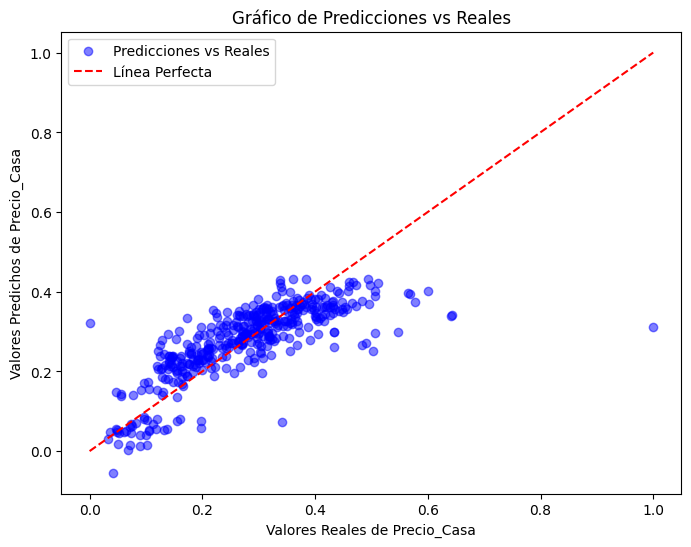

In [19]:
#Gráfica de Dispersión
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label="Predicciones vs Reales")
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label="Línea Perfecta")
plt.xlabel("Valores Reales de Precio_Casa")
plt.ylabel("Valores Predichos de Precio_Casa")
plt.title("Gráfico de Predicciones vs Reales")
plt.legend()
plt.show()